In [1]:
import os
os.chdir('../../../..')

In [28]:
import json
import chemiscope
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

from pymatgen.io.ase import AseAtomsAdaptor
from pymatgen.core import Structure
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.manifold import TSNE

from src.datasets import MaterialsProject
from src.non_euclidean import _compute_invariant_feature_matrix as invariant_matrix

In [18]:
mp = MaterialsProject()
df = mp.load()

2026-03-24 11:06:05.469 | INFO     | src.datasets:load:1020 - Loading cached Parquet data from data/Materials Project/stable_oxides.parquet...


In [26]:
df = df.with_columns(
        pl.format("a: {}, b: {}, c: {}", 
                  pl.col("a").round(3), 
                  pl.col("b").round(3), 
                  pl.col("c").round(3)).alias("lattice_str")
    )

df = df.with_columns(
        pl.format("alpha: {}, beta: {}, gamma: {}", 
                  pl.col("alpha").round(3), 
                  pl.col("beta").round(3), 
                  pl.col("gamma").round(3)).alias("angles_str")
    )

In [19]:
df.head(2)

material_id,formula_pretty,energy_per_atom,formation_energy_per_atom,band_gap,is_metal,raw_structure,crystal_system,space_group,density,a,b,c,alpha,beta,gamma,volume,num_sites,soap_embedding,acsf_embedding
str,str,f64,f64,f64,bool,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,i64,list[f64],list[f64]
"""mp-19359""","""NaFeO2""",-6.72479,-1.797874,1.9919,false,"""{""@module"": ""pymatgen.core.str…","""Trigonal""","""R-3m""",4.371677,5.614292,5.614292,5.614291,31.183234,31.183221,31.183226,42.099058,4,"[38.712658, 114.179498, … 138.847002]","[0.0, 0.0, … 0.0]"
"""mp-3098""","""AlCuO2""",-6.8528,-2.417624,1.8148,false,"""{""@module"": ""pymatgen.core.str…","""Hexagonal""","""P6_3/mmc""",5.146334,2.842773,2.842773,11.297846,90.0,90.0,120.000003,79.069786,8,"[47.437852, 131.548353, … 522.766598]","[0.0, 0.0, … 0.0]"


In [6]:
adaptor = AseAtomsAdaptor()
frames_unit = [] 

for struct_json in mp.df["raw_structure"]:
    struct = Structure.from_dict(json.loads(struct_json))
    prim = struct.get_primitive_structure()
    
    if len(prim) < 3:
        prim.make_supercell([2, 2, 2])
        
        while len(prim) < 3:
            prim.make_supercell([2, 2, 2])
            
    frames_unit.append(adaptor.get_atoms(prim))


In [13]:
matrices = [invariant_matrix(frames) for frames in frames_unit]

max_atoms = max(matrix.shape[1] for matrix in matrices)
num_properties = matrices[0].shape[0]

flattened_padded_matrices = []

for matrix in matrices:
    current_atoms = matrix.shape[1]
    
    padded_matrix = np.zeros((num_properties, max_atoms))
    
    padded_matrix[:, :current_atoms] = matrix
    
    vector = padded_matrix.flatten()
    flattened_padded_matrices.append(vector)

X = np.array(flattened_padded_matrices)

Evaluating cluster numbers. This may take a moment...


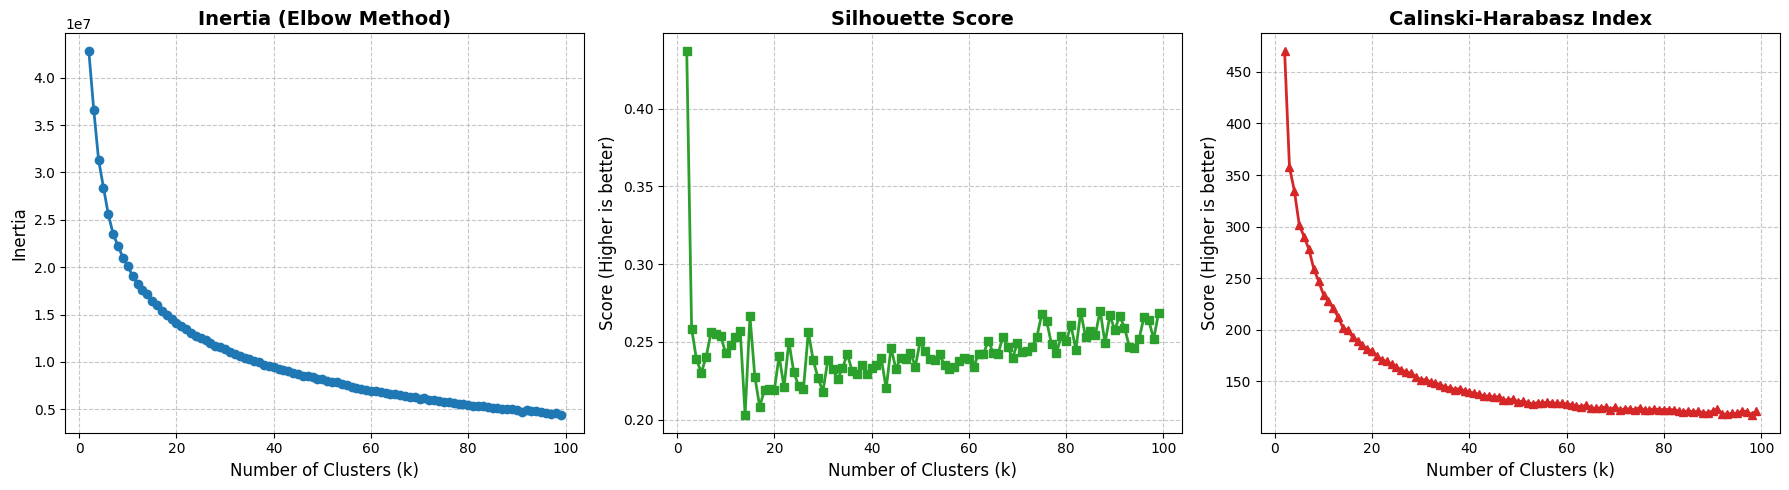

Optimal clusters based on Silhouette Score: 2
Optimal clusters based on Calinski-Harabasz: 2

Refitting KMeans with optimal k=2...


In [15]:
k_range = range(2, 100)

inertias = []
silhouette_scores = []
ch_scores = []

print("Evaluating cluster numbers. This may take a moment...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))
    ch_scores.append(calinski_harabasz_score(X, labels))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(k_range, inertias, marker='o', linestyle='-', color='tab:blue', linewidth=2)
axs[0].set_title('Inertia (Elbow Method)', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axs[0].set_ylabel('Inertia', fontsize=12)
axs[0].grid(True, linestyle='--', alpha=0.7)

axs[1].plot(k_range, silhouette_scores, marker='s', linestyle='-', color='tab:green', linewidth=2)
axs[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axs[1].set_ylabel('Score (Higher is better)', fontsize=12)
axs[1].grid(True, linestyle='--', alpha=0.7)

axs[2].plot(k_range, ch_scores, marker='^', linestyle='-', color='tab:red', linewidth=2)
axs[2].set_title('Calinski-Harabasz Index', fontsize=14, fontweight='bold')
axs[2].set_xlabel('Number of Clusters (k)', fontsize=12)
axs[2].set_ylabel('Score (Higher is better)', fontsize=12)
axs[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

best_k_silhouette = k_range[np.argmax(silhouette_scores)]
best_k_ch = k_range[np.argmax(ch_scores)]

print(f"Optimal clusters based on Silhouette Score: {best_k_silhouette}")
print(f"Optimal clusters based on Calinski-Harabasz: {best_k_ch}")

best_k = best_k_silhouette
print(f"\nRefitting KMeans with optimal k={best_k}...")

best_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = best_kmeans.fit_predict(X)

In [20]:
num_clusters = 2
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X)

Running t-SNE on 1000 samples...


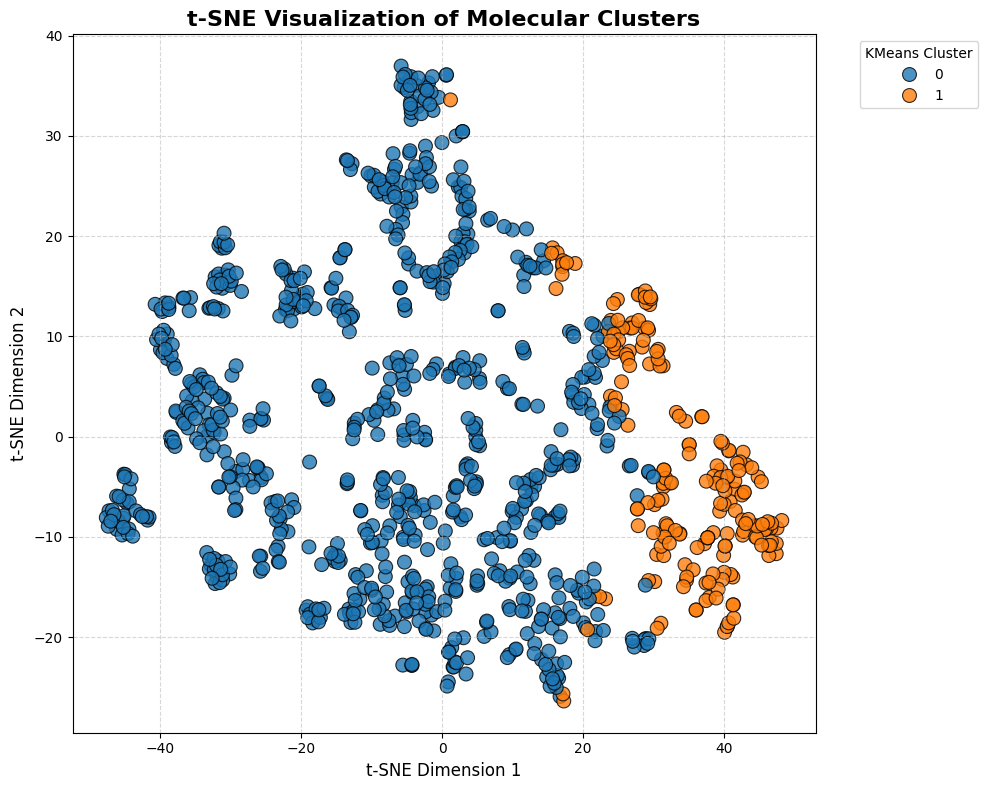

In [21]:
n_samples = X.shape[0]
perplexity_value = min(30, n_samples - 1)

print(f"Running t-SNE on {n_samples} samples...")

tsne = TSNE(
    n_components=2, 
    random_state=42, 
    perplexity=perplexity_value,
    init='pca',
    learning_rate='auto'
)

X_tsne = tsne.fit_transform(X)

# 2. Create the plot
plt.figure(figsize=(10, 8))

# Using Seaborn to create a scatter plot, colored by the KMeans cluster labels
sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1], 
    hue=cluster_labels, 
    palette="tab10",  # distinct colors for different clusters
    s=100,            # marker size
    alpha=0.8,        # slight transparency
    edgecolor="k"     # black borders around dots
)

plt.title("t-SNE Visualization of Molecular Clusters", fontsize=16, fontweight='bold')
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)

plt.legend(title="KMeans Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [30]:
properties = {
        "t-SNE 1": X_tsne[:, 0],
        "t-SNE 2": X_tsne[:, 1],
        "Cluster": cluster_labels,
        "Material ID": df["material_id"].to_list(),
        "Formula": df["formula_pretty"].to_list(),
        "Crystal System": df["crystal_system"].to_list(),
        "Space Group": df["space_group"].to_list(),
        "Energy per Atom": df["energy_per_atom"].to_numpy(),
        "Formation Energy": df["formation_energy_per_atom"].to_numpy(),
        "Density": df["density"].to_numpy(),
        "Volume": df["volume"].to_numpy(),
        "Lattice (a,b,c)": df["lattice_str"].to_list(),
        "Angles (alpha, beta, gamma)" : df["angles_str"].to_list(),
    }

widget = chemiscope.show(
        structures=frames_unit,
        properties=properties,
    )

widget


<ChemiscopeWidget(meta={'name': ' '}, structures=[{'size': 4, 'data': 'structure-0'}, {'size': 8, 'data': 'str…